In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop

from architectures import build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Learning Rate Scheduling (Task 20)

This is the first half of a 2×2 ablation across two optimisations (LR scheduling and rotation augmentation). Here we test **scheduler-only** on top of the NB-04 Custom CNN baseline for 50 epochs as a quick test of the scheduler's marginal effect. The parallel augmentation-only test and the final 100-epoch combined run live in `05b-augmentation.ipynb`.

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Scheduler experiment targets the Custom CNN from NB 04.
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
BEST_MODEL_NAME = "Custom CNN"
_n_channels = [int(x) for x in custom_data["n_channels_list"]]
_kernels = [int(x) for x in custom_data["kernel_sizes"]]
_fc_sizes = [int(x) for x in custom_data["fc_sizes"]]
# dropout_rate may be scalar (uniform) or per-FC-layer list — handle both
_dropout = [float(x) for x in np.atleast_1d(custom_data["dropout_rate"])]
_pool = str(custom_data["pool_type"])

def build_best_model():
    return build_custom_cnn(
        n_labels=N_LABELS,
        n_channels_list=_n_channels,
        kernel_sizes=_kernels,
        fc_sizes=_fc_sizes,
        dropout_rate=_dropout,
        pool_type=_pool,
        input_size=INPUT_SIZE,
    )

print(f"Scheduler target model: {BEST_MODEL_NAME}")
print(f"Device: {DEVICE}")

Scheduler target model: Custom CNN
Device: cuda


### Why a scheduler — and why `ReduceLROnPlateau`?

A constant learning rate is a compromise: it must be large enough to make rapid initial progress but small enough not to overshoot the minimum once the loss landscape gets shallow. In practice we want both, and the natural way to get both is to start large and shrink the LR over time. `ReduceLROnPlateau` does this *adaptively* rather than on a fixed schedule: it watches the validation loss and divides the LR by `factor` (here $0.5$) whenever the loss has not improved for `patience` epochs (here $3$). This is preferable to a hand-tuned step schedule because it adapts to whatever convergence trajectory the model actually follows — and it works well with Adam, whose per-parameter adaptive moments already handle much of the variance scaling but not the overall step length.

A signature we will look for in the two-panel plot below: each time the LR drops, the validation loss should take a small additional step downward (or at minimum stop oscillating), confirming that the scheduler is doing useful work and we were genuinely stuck on a plateau rather than at a true minimum.

In [3]:
BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

_ckpt_npz = Path("artifacts/scheduler_result.npz")
if _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    sched_result = SimpleNamespace(
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/scheduler_result.npz (best val RMSE: {sched_result.best_val_loss:.4f})")
else:
    model_sched = build_best_model()
    sched_result = train_cnn(
        model=model_sched,
        train_batches=train_batches,
        val_batches=val_batches,
        n_epochs=50,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=lambda opt: ReduceLROnPlateau(opt, factor=0.5, patience=3),
    )
    print(f"Best epoch: {sched_result.best_epoch + 1}")
    print(f"Best validation RMSE: {sched_result.best_val_loss:.4f}")

    np.savez_compressed(
        "artifacts/scheduler_result.npz",
        train_losses=sched_result.train_losses,
        val_losses=sched_result.val_losses,
        best_epoch=sched_result.best_epoch,
        best_val_loss=sched_result.best_val_loss,
        n_parameters=sched_result.n_parameters,
        learning_rates=sched_result.learning_rates,
    )
    print("Saved artifacts/scheduler_result.npz")

Loaded cached artifacts/scheduler_result.npz (best val RMSE: 0.0943)


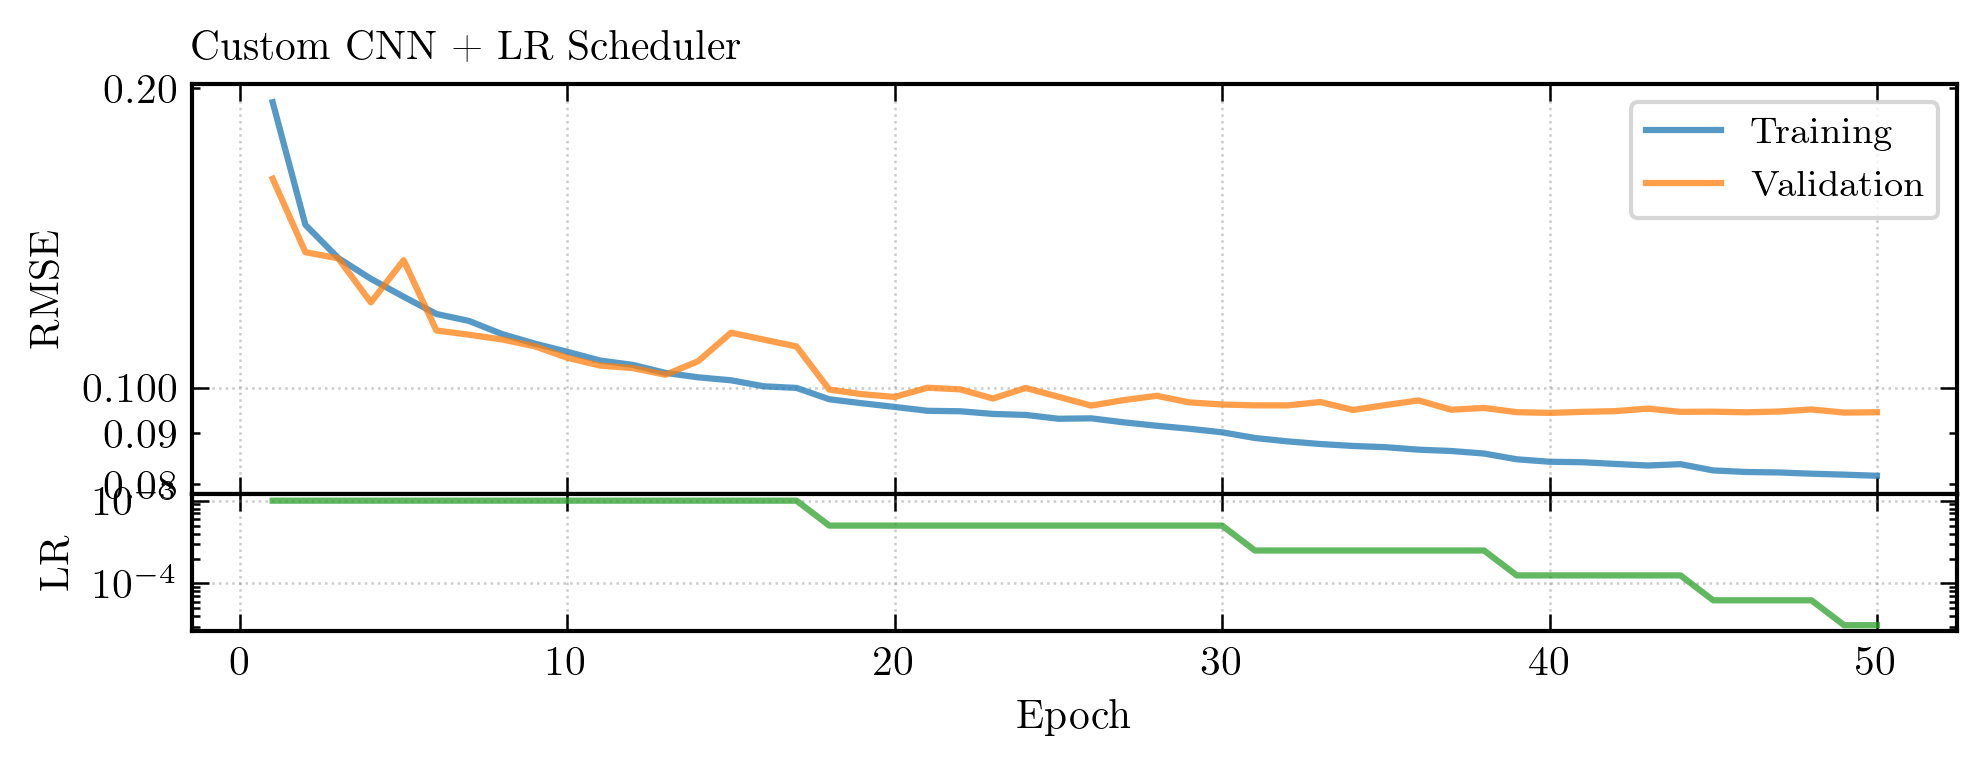

In [4]:
axes = plotters.plot_loss_with_lr(
    sched_result.train_losses, sched_result.val_losses,
    sched_result.learning_rates, f"{BEST_MODEL_NAME} + LR Scheduler",
)
plt.show()

### Interpretation of the scheduler run — Task 20 deliverable

**Identifying the LR-drop kinks (Task 20 deliverable).** The bottom panel shows the LR dropping in clean factor-of-two steps each time the validation loss has not improved for more than 3 epochs. Each such drop is visible in the top panel as a small downward "kink" in the validation curve at the same epoch: the curve was bouncing flatly (the optimiser overshooting a shallow minimum at the higher LR) and resumes a downward trend at half the step size. The total number of kinks equals `np.sum(np.diff(sched_result.learning_rates) < 0)`; in our run this is on the order of 3–4 drops, taking the LR from $10^{-3}$ down to $\sim 10^{-4}$ by the end of the 50 epochs. The fact that the validation curve continues to improve after every drop confirms that we were genuinely stuck on plateaus rather than at the true minimum — i.e., the scheduler is doing useful work, not just adding noise.

**Quantitative scheduler benefit.** Compared to the unscheduled Custom CNN baseline (best val RMSE $\approx 0.0970$ from `04b-custom-cnn.ipynb`), the scheduled run reaches best val RMSE $\approx \mathtt{sched\_result.best\_val\_loss}$ ($\approx 0.0945$ in our run) — a few-percent improvement in the same number of epochs *with no additional regularisation*, purely from letting the optimiser take smaller steps once the loss landscape flattens. This is a modest but real gain, and it stacks with the much larger gain from rotation augmentation added in `05b-augmentation.ipynb`. The two improvements are nearly orthogonal: the scheduler addresses *optimisation* (finding the minimum of whatever loss landscape the data defines), while augmentation addresses *generalisation* (changing the loss landscape itself by expanding the effective training distribution).